In [1]:
from src.data_processing import load_data
import matplotlib.pyplot as plt

In [6]:
df =load_data("CMAPSSData/train_FD001.txt")
df.head()

,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


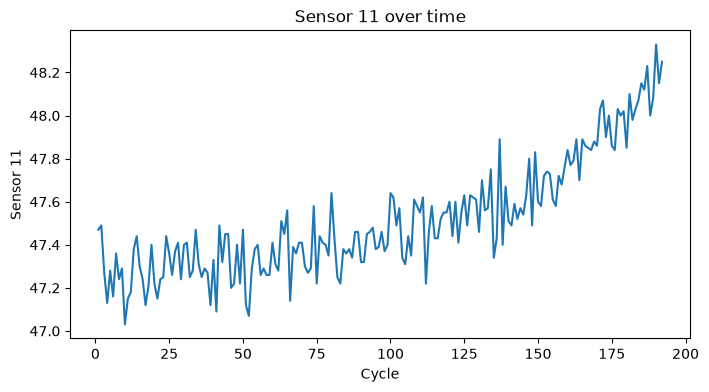

In [15]:
# Visualize sensor X for engine Y
X = 11
Y = 1
subset = df[df["unit"] == Y]

plt.figure(figsize=(8,4))
plt.plot(subset["cycle"], subset[f"s{X}"])
plt.xlabel("Cycle")
plt.ylabel(f"Sensor {X}")
plt.title(f"Sensor {X} over time")
plt.show() 

This means that the sensor degradation is time dependent.

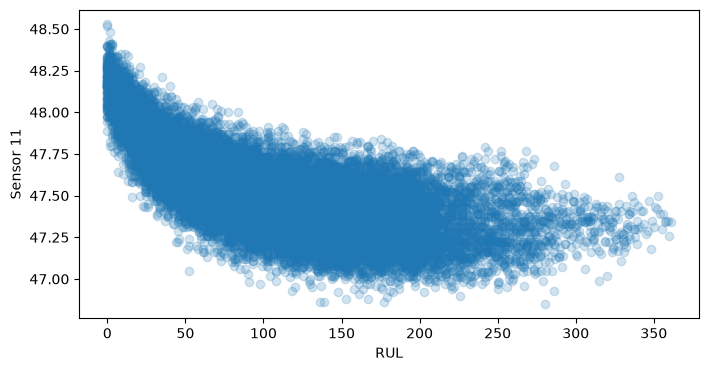

In [16]:
plt.figure(figsize=(8,4))
plt.scatter(df["RUL"], df["s11"], alpha=0.2)
plt.xlabel("RUL")
plt.ylabel("Sensor 11")
plt.show()

The relationship could be linear with a transformation

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [28]:
features = [col for col in df.columns if col not in ["unit", "cycle", "RUL"]]

X = df[features]
y = df["RUL"]

train_units = df["unit"].unique()[:80]
test_units = df["unit"].unique()[80:]

train_df = df[df["unit"].isin(train_units)]
test_df = df[df["unit"].isin(test_units)]

X_train = train_df[features]
y_train = train_df["RUL"]
y_train_log = np.log1p(y_train)

X_test = test_df[features]
y_test = test_df["RUL"]

In [29]:
reg = LinearRegression()
reg.fit(X_train, y_train_log)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](24,)","[ 1.38,19.97, 0. ,..., 0. , 0.28, 0.51]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](24,)","['op1','op2','op3',...,'s19','s20','s21']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4293
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,24
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,17


In [30]:
y_pred = np.expm1(reg.predict(X_test))

In [31]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE = {rmse:.2f}")
print(f"R²   = {r2:.2f}")

RMSE = 57.15
R²   = 0.46


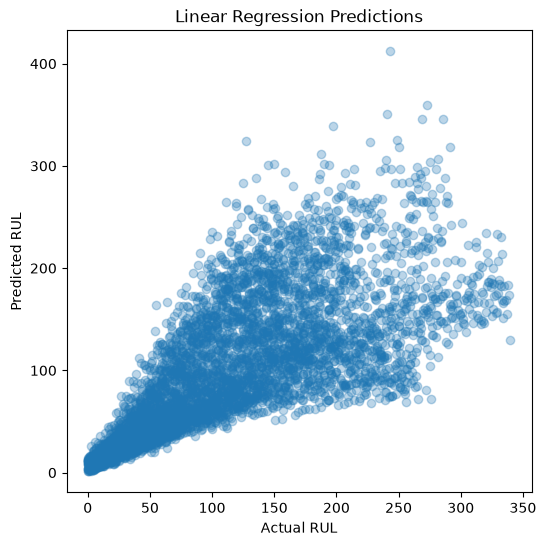

In [32]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Linear Regression Predictions")
plt.show()